In [24]:
from sdv.datasets.local import load_csvs
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer
from sdv.evaluation.single_table import evaluate_quality

## Use SDV to generate synthetic data fro a single tabular dataset

In [25]:
# Load one csv file in `real_data` directory
data = load_csvs(folder_name='real_data')

/home/luzhenna/miniconda3/envs/synth/lib/python3.12/site-packages/sdv/datasets/local.py:36: UserWarning: Ignoring incompatible files ['sdv_demo_fake_hotel_guests_dataset.csv:6E53BFF5-0001-412b-8407-E3AEDE763511'] in folder 'real_data'.
  warnings.warn(f"Ignoring incompatible files {other_files} in folder '{folder_name}'.")


In [26]:
# auto-detect metadata
# metadata = Metadata.detect_from_dataframes(data)
# load metadata from file
metadata = Metadata.load_from_json('metadata_fake_hotel_guests.json')

In [27]:
# preview real data 
data['sdv_demo_fake_hotel_guests_dataset'].head(3)

,index,name,age,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,1,Wang Bin,30,michaelsanders@shaw.net,False,BASIC,37.89,27-Dec-20,29-Dec-20,131.23,"49380 Rivers Street\nSpencerville, AK 68265",4.075085e+18
1,2,Sharma Manish,23,randy49@brown.biz,False,BASIC,24.37,30-Dec-20,2-Jan-21,114.43,"88394 Boyle Meadows\nConleyberg, TN 22063",1.800730e+14
2,3,Avery Scott,42,webermelissa@neal.com,True,DELUXE,0.00,17-Sep-20,18-Sep-20,368.33,"0323 Lisa Station Apt. 208\nPort Thomas, LA 82585",3.898350e+13


In [28]:
synthesizer = CTGANSynthesizer(
    metadata,
    enforce_rounding=False,
    epochs=500,
    verbose=True
)

Add constraints so that `check_out_dates` are always later than `check_in_dates`.

In [29]:
positive_constraint = {
    'constraint_class': 'Positive',
    'constraint_parameters': {
        'column_name': 'room_rate',
        'strict_boundaries': True
    }
}

In [30]:
age_constraint = {
    'constraint_class': 'ScalarRange',
    'constraint_parameters': {
        'column_name': 'age',
        'low_value': 18,
        'high_value': 60,
        'strict_boundaries': True
    }
}

In [31]:
date_constraint ={
    'constraint_class': 'Inequality',
    'constraint_parameters': {
        'low_column_name': 'checkin_date',
        'high_column_name': 'checkout_date',
        'strict_boundaries': True
    }
}

In [32]:
synthesizer.add_constraints(
    constraints=[date_constraint, age_constraint, positive_constraint],
)

In [33]:
data['sdv_demo_fake_hotel_guests_dataset']

,index,name,age,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,1,Wang Bin,30,michaelsanders@shaw.net,False,BASIC,37.89,27-Dec-20,29-Dec-20,131.23,"49380 Rivers Street\nSpencerville, AK 68265",4.075085e+18
1,2,Sharma Manish,23,randy49@brown.biz,False,BASIC,24.37,30-Dec-20,2-Jan-21,114.43,"88394 Boyle Meadows\nConleyberg, TN 22063",1.800730e+14
2,3,Avery Scott,42,webermelissa@neal.com,True,DELUXE,0.00,17-Sep-20,18-Sep-20,368.33,"0323 Lisa Station Apt. 208\nPort Thomas, LA 82585",3.898350e+13
3,4,Daniel Lewis,35,gsims@terry.com,False,BASIC,NaN,28-Dec-20,31-Dec-20,115.61,"77 Massachusetts Ave\nCambridge, MA 02139",4.969552e+15
4,5,Victoria Robinson,28,misty33@smith.biz,False,BASIC,16.45,5-Apr-20,NaN,122.41,"1234 Corporate Drive\nBoston, MA 02116",3.558513e+15
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Zhang Hui,39,laurabennett@jones-duncan.net,False,BASIC,8.71,4-Jan-21,6-Jan-21,103.25,"5678 Office Road\nSan Francisco, CA 94103",3.505516e+15
496,497,Patel Akash,33,johnny71@cook.info,False,BASIC,16.31,24-Aug-20,26-Aug-20,115.81,"953 White Island\nChristopherside, TN 91366",2.224525e+15
497,498,Grace Perry,32,ygarcia@ballard-lopez.net,False,BASIC,30.59,11-Nov-20,13-Nov-20,141.61,"5678 Office Road\nSan Francisco, CA 94103",1.800960e+14
498,499,Michael Roberts,34,thomasdale@hall.com,False,BASIC,1.93,16-Jul-20,18-Jul-20,136.92,"5678 Office Road\nSan Francisco, CA 94103",4.488220e+12


In [34]:
synthesizer.fit(data['sdv_demo_fake_hotel_guests_dataset'])


Gen. (-1.09) | Discrim. (-0.16): 100%|██████████| 500/500 [00:37<00:00, 13.26it/s]


In [35]:
synthetic_data = synthesizer.sample(500)

Sampling rows:   0%|          | 0/500 [00:00<?, ?it/s]

Sampling rows: 100%|██████████| 500/500 [00:00<00:00, 648.27it/s]


In [36]:
evaluate_quality(
        data['sdv_demo_fake_hotel_guests_dataset'],
        synthetic_data,
        metadata)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 154.70it/s]|
Column Shapes Score: 82.35%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 223.42it/s]|
Column Pair Trends Score: 84.69%

Overall Score (Average): 83.52%



## Compare data generated by SDV vs. LLM

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# load csv file generated by LLM
df_llm = pd.read_csv('synthetic_output_LLM_sdv_demo_fake_hotel_guests_dataset.csv')

In [13]:
# get the list of columns that are not NaN
not_nan_columns = df_llm.columns[df_llm.notna().any()].tolist()

In [14]:
# load csv file generated by SDV
df_sdv = pd.read_csv('synthetic_data_sdv.csv')

In [15]:
# get a subset of columns that are not NaN in LLM
df_sdv_subset = df_sdv[not_nan_columns]
df_llm_subset = df_llm[not_nan_columns]

In [10]:
df_sdv_subset

,name,age,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate
0,Tom Prince,38,False,DELUXE,4.35,2020-06-21,2020-06-22,240.12
1,John Roberts,33,False,BASIC,25.80,2020-11-21,2020-11-22,156.97
2,Billy Murphy,35,False,BASIC,1.76,2020-03-31,2020-04-01,194.09
3,Maria Roy,38,True,DELUXE,0.04,2020-09-20,2020-09-21,281.35
4,Sandra Mercado,30,False,BASIC,0.48,2020-05-17,2020-05-18,96.26
...,...,...,...,...,...,...,...,...
495,Ricardo Wang,46,False,BASIC,NaN,2020-11-15,2020-11-16,183.51
496,Miguel Lynn,39,True,BASIC,37.73,2020-04-03,2020-04-06,100.71
497,John Taylor,36,True,BASIC,0.00,2020-02-04,NaN,173.13
498,Mr. Jeffrey Copeland,29,True,SUITE,0.06,2020-03-10,2020-03-11,97.94


/tmp/ipykernel_76818/1389399382.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df_sdv_subset, palette='Set2', ax=axs[0])
/tmp/ipykernel_76818/1389399382.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df_llm_subset, palette='Set2', ax=axs[1])


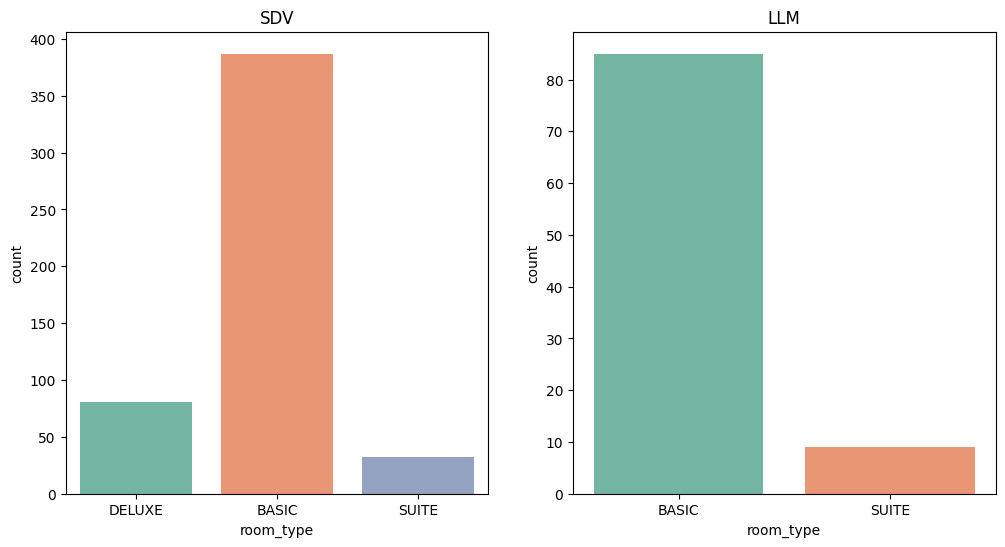

In [ ]:
# get a bar plot of room_type in df_sdv_subset and in df_llm_subset
# arrange in subplots

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
sns.countplot(x='room_type', data=df_sdv_subset, palette='Set2', ax=axs[0])
axs[0].set_title('SDV')
sns.countplot(x='room_type', data=df_llm_subset, palette='Set2', ax=axs[1])
axs[1].set_title('LLM')
plt.show()

In [6]:
df_sdv

,index,name,age,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,16189848,Tom Prince,38,dsullivan@example.net,False,DELUXE,4.35,2020-06-21,2020-06-22,240.12,"90469 Karla Knolls Apt. 781\nSusanberg, CA 70033",1.800527e+14
1,12023745,John Roberts,33,steven59@example.org,False,BASIC,25.80,2020-11-21,2020-11-22,156.97,"6108 Carla Ports Apt. 116\nPort Evan, MI 71694",3.597462e+15
2,15287077,Billy Murphy,35,brandon15@example.net,False,BASIC,1.76,2020-03-31,2020-04-01,194.09,86709 Jeremy Manors Apt. 786\nPort Garychester...,4.506225e+18
3,15968702,Maria Roy,38,humphreyjennifer@example.net,True,DELUXE,0.04,2020-09-20,2020-09-21,281.35,"8906 Bobby Trail\nEast Sandra, NY 43986",3.508887e+15
4,2886621,Sandra Mercado,30,joshuabrown@example.net,False,BASIC,0.48,2020-05-17,2020-05-18,96.26,"732 Dennis Lane\nPort Nicholasstad, DE 49786",3.018331e+13
...,...,...,...,...,...,...,...,...,...,...,...,...
495,3826536,Ricardo Wang,46,donnaodom@example.net,False,BASIC,NaN,2020-11-15,2020-11-16,183.51,"328 Danny Haven Apt. 575\nBrownbury, FM 31800",4.783783e+18
496,16138282,Miguel Lynn,39,tammycarey@example.net,True,BASIC,37.73,2020-04-03,2020-04-06,100.71,"48578 Parker Underpass\nBradybury, VA 45723",4.271372e+15
497,15662531,John Taylor,36,gwebb@example.org,True,BASIC,0.00,2020-02-04,NaN,173.13,"590 Peterson Roads Apt. 892\nLake Phillip, NE ...",4.462947e+18
498,7169890,Mr. Jeffrey Copeland,29,carlnovak@example.com,True,SUITE,0.06,2020-03-10,2020-03-11,97.94,"2854 Steven Haven\nWest Michael, NE 22990",3.519002e+15


In [4]:
df_llm

,index,name,age,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,NaN,James Smith,34,NaN,False,BASIC,0.0,23-Aug-20,25-Apr-20,107.23,NaN,NaN
1,NaN,Emma Johnson,35,NaN,False,BASIC,0.0,27-Dec-20,14-May-20,109.56,NaN,NaN
2,NaN,Michael Williams,36,NaN,False,BASIC,1.2,19-Jan-20,02-Jun-20,110.78,NaN,NaN
3,NaN,Olivia Brown,33,NaN,False,BASIC,1.7,23-Aug-20,19-Jul-20,112.45,NaN,NaN
4,NaN,William Jones,37,NaN,False,BASIC,2.3,05-Nov-20,08-Aug-20,114.98,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
89,NaN,Annabelle Knight,38,NaN,True,SUITE,20.5,26-Dec-20,29-Jul-20,249.78,NaN,NaN
90,NaN,Jason Stanley,35,NaN,False,BASIC,NaN,03-Dec-20,17-Aug-20,251.45,NaN,NaN
91,NaN,Isabelle Simmons,37,NaN,False,BASIC,0.0,10-Jul-20,06-Oct-20,253.12,NaN,NaN
92,NaN,Oscar Dunn,34,NaN,False,BASIC,1.5,17-Jul-20,21-Oct-20,254.78,NaN,NaN
